In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load the cleaned dataset
df = pd.read_csv("online_retail_cleaned.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Display the first five rows
display(df.head())

Dataset loaded successfully!
Dataset shape: (524878, 14)


C:\Users\user\AppData\Local\Temp\ipykernel_24316\4003318764.py:9: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("online_retail_cleaned.csv")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday


In [4]:
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nFIRST FEW RECORDS:")
display(df.head(3))

COLUMN NAMES:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalSales', 'Year', 'Month', 'MonthName', 'Day', 'DayOfWeek']

DATA TYPES:
InvoiceNo       object
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
TotalSales     float64
Year             int64
Month            int64
MonthName          str
Day              int64
DayOfWeek          str
dtype: object

FIRST FEW RECORDS:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday


In [5]:
# Convert InvoiceDate back to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create a Year-Month column for trend analysis
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue
monthly_sales = (
    df.groupby("YearMonth")["TotalSales"]
    .sum()
    .reset_index()
)

# Convert YearMonth to timestamp for plotting
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].dt.to_timestamp()

# Display the calculated monthly sales data
display(monthly_sales.head())

,YearMonth,TotalSales
0,2010-12-01,821452.730
1,2011-01-01,689811.610
2,2011-02-01,522545.560
3,2011-03-01,716215.260
4,2011-04-01,536968.491


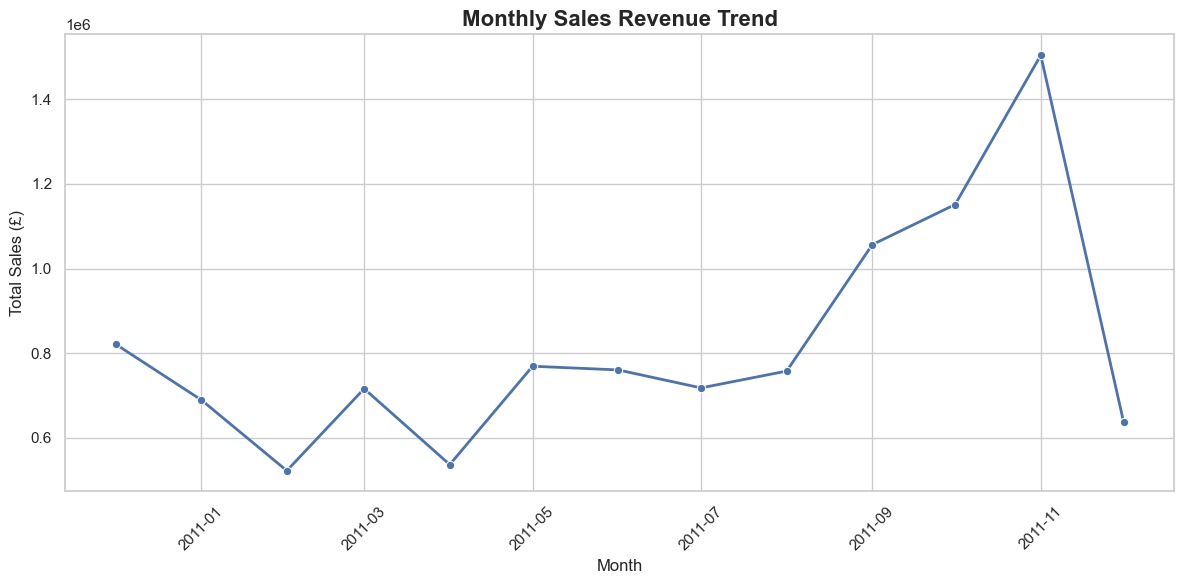

In [6]:
# Set a clean visualization style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(12, 6))

# Plot monthly revenue trend
sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="TotalSales",
    marker="o",
    linewidth=2
)

# Add titles and labels
plt.title("Monthly Sales Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")

# Improve date labels
plt.xticks(rotation=45)
plt.tight_layout()

# Display the chart
plt.show()

In [7]:
# Calculate revenue generated by each product
top_products = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Display the Top 10 products
display(top_products)

,Description,TotalSales
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


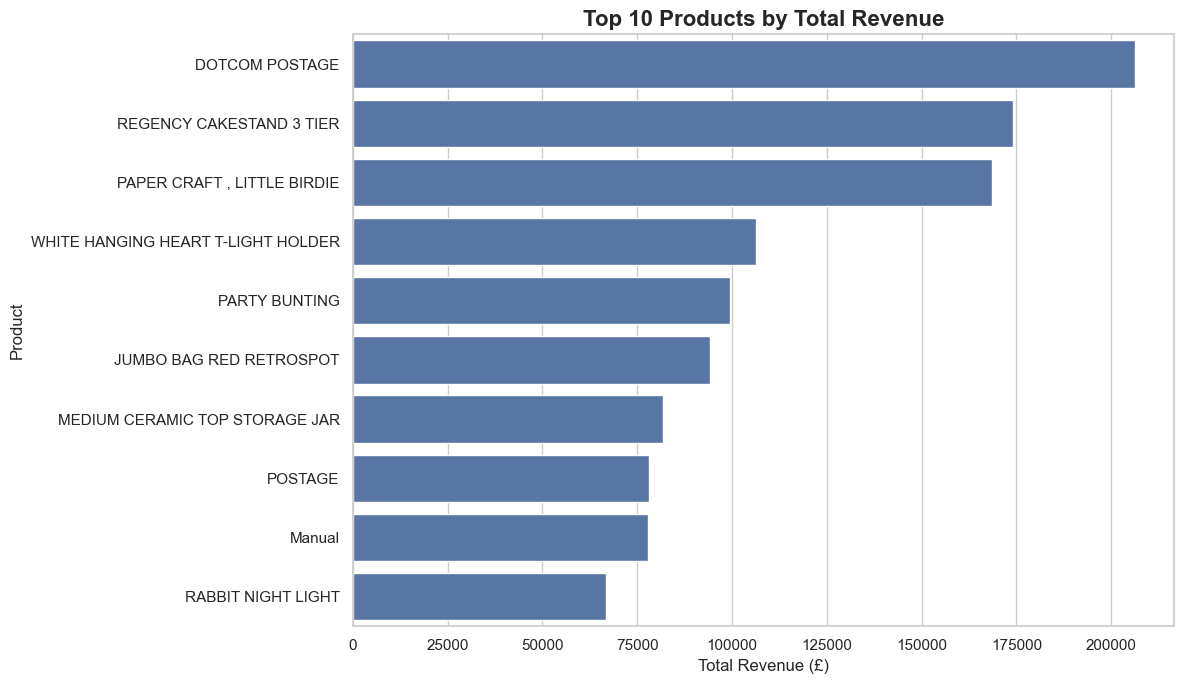

In [8]:
# Create Top 10 Products by Revenue visualization

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x="TotalSales",
    y="Description"
)

plt.title("Top 10 Products by Total Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [9]:
# Calculate total revenue by country
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("TOP 10 COUNTRIES BY REVENUE")
display(country_sales)

TOP 10 COUNTRIES BY REVENUE


,Country,TotalSales
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


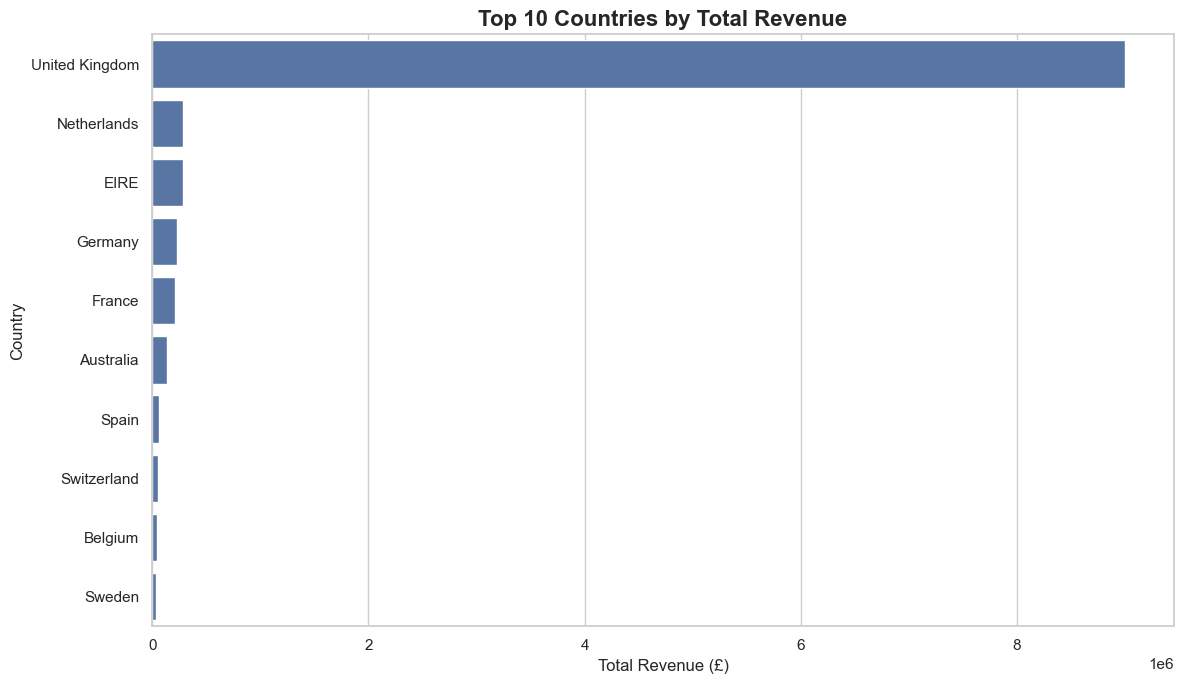

In [10]:
# Create Top 10 Countries by Revenue visualization

plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_sales,
    x="TotalSales",
    y="Country"
)

plt.title("Top 10 Countries by Total Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [11]:
# Revenue by Day of Week

day_sales = (
    df.groupby("DayOfWeek")["TotalSales"]
    .sum()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
    .reset_index()
)

print("REVENUE BY DAY OF WEEK")
display(day_sales)

REVENUE BY DAY OF WEEK


,DayOfWeek,TotalSales
0,Monday,1775782.071
1,Tuesday,2175700.511
2,Wednesday,1847074.380
3,Thursday,2199292.570
4,Friday,1837470.491
5,Saturday,NaN
6,Sunday,806790.781


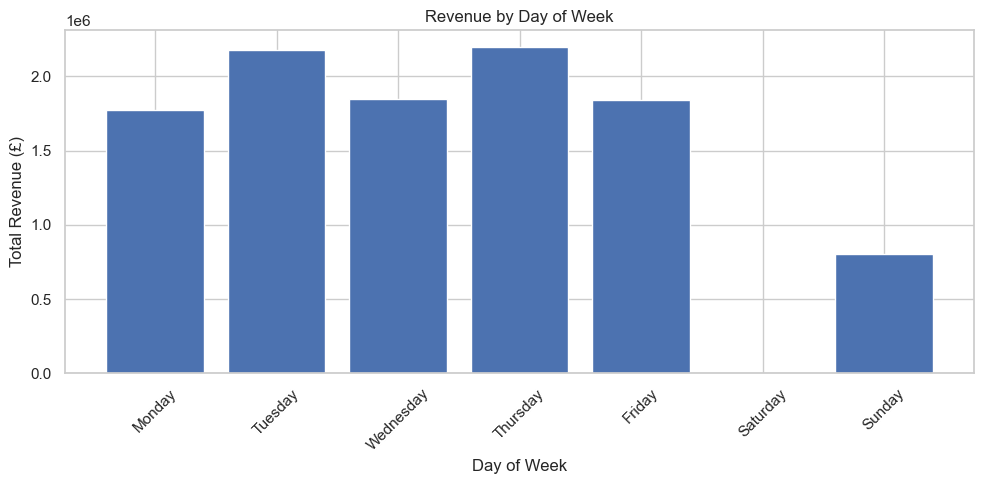

In [12]:
# Bar chart: Revenue by Day of Week

plt.figure(figsize=(10, 5))

plt.bar(day_sales["DayOfWeek"], day_sales["TotalSales"])

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# Replace missing revenue values with 0
day_sales["TotalSales"] = day_sales["TotalSales"].fillna(0)

display(day_sales)

,DayOfWeek,TotalSales
0,Monday,1775782.071
1,Tuesday,2175700.511
2,Wednesday,1847074.380
3,Thursday,2199292.570
4,Friday,1837470.491
5,Saturday,0.000
6,Sunday,806790.781


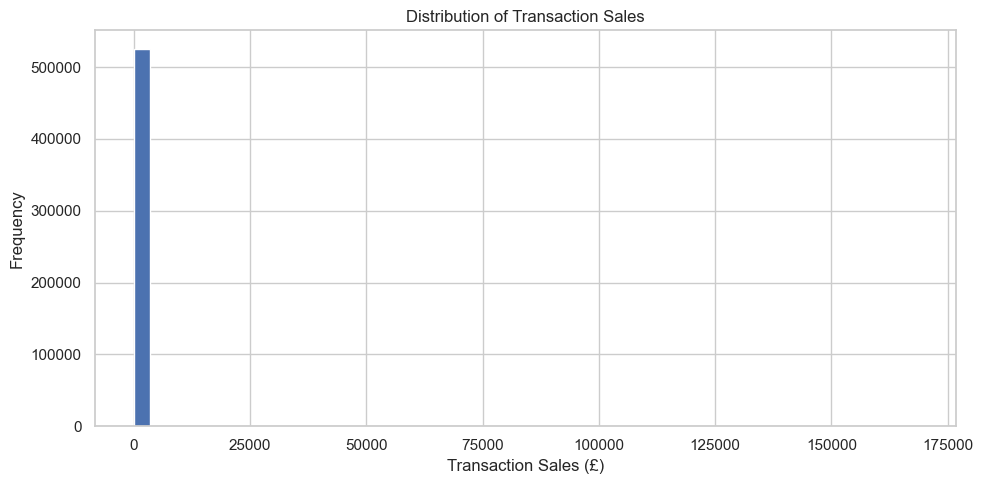

In [14]:
# Distribution of transaction sales values

plt.figure(figsize=(10, 5))

plt.hist(df["TotalSales"], bins=50)

plt.title("Distribution of Transaction Sales")
plt.xlabel("Transaction Sales (£)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

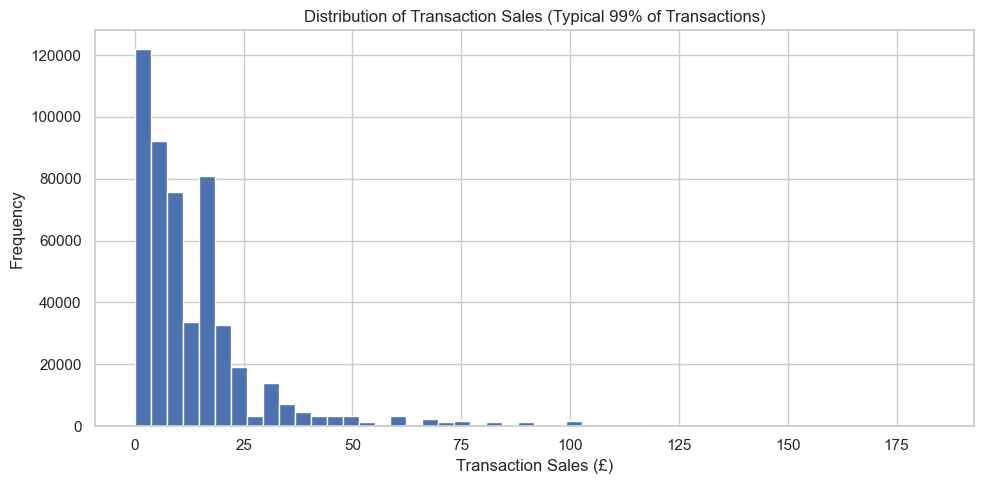

99th percentile transaction value: £183.60


In [15]:
# Improved sales distribution excluding the top 1% for visualization

upper_limit = df["TotalSales"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    df[df["TotalSales"] <= upper_limit]["TotalSales"],
    bins=50
)

plt.title("Distribution of Transaction Sales (Typical 99% of Transactions)")
plt.xlabel("Transaction Sales (£)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"99th percentile transaction value: £{upper_limit:,.2f}")